In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import datetime as dt
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Analyses of price and return dynamics between South Korean KOSPI equity index and the South Korean equity tracking ETF EWY

## Raymon Goh

*Since April 2025, with the onset of President Donald Trump's Liberation Day tariffs, institutional interest in diversifying the geographical concentration of holdings has increased, leading to large inflows into leading equities of emerging markets.*

*South Korea has been one of the standouts of this Anywhere-But-The-USA trade. With South Korea's stock market being dominated heavily by memory semiconductor companies, such as Samsung Electronics and SK hynix, the inflow of funds was driven by a two-pronged investment narrative: Investors who wanted to invest in strong companies outside of the USA, and investors who wanted a slice of the AI pie allocated to memory semiconductors.*

*With this in mind, and my interest in all things South Korean, I have been closely watching the South Korean market. After the 삼일절 market holiday in South Korea on 2nd Mar 2026, from day to day, I noticed that the correlation between the KOSPI index and EWY ETF seemed to have been decoupled. Eventually (i.e. now) I have decided to formalise this by looking into their relationship, and potentially devise a trading strategy to compete with the KOSPI's miracle run.*

### Functions

In [7]:
def setup_returns(df):
    """
    Sets up daily returns and respective cumulative return columns in a dataframe
    """
    df['Returns'] = df['Adj Close'].pct_change().values
    df['Cumulative Returns'] = (1 + df['Returns'].fillna(0)).cumprod()
    return df

def setup_weekly_returns(df):
    """
    Sets up weekly returns and respective cumulative return columns in a dataframe
    """
    df.index = pd.to_datetime(df.index)
    
    weekly_df = df.resample('W').last()
    weekly_df['Returns'] = weekly_df['Adj Close'].pct_change()
    weekly_df['Cumulative Returns'] = (1 + weekly_df['Returns'].fillna(0)).cumprod()
    return weekly_df[['Adj Close', 'Returns', 'Cumulative Returns']]

In [8]:
def calc_max_dd(series):
    max_dd = 0.0
    s = series.values
    cumu_max = 1 + s[0]
    curr_cumu = 1 + s[0]
    for r in s[1:]:
        curr_cumu = (1 + r) * curr_cumu
        cumu_max = max(curr_cumu, cumu_max)
        max_dd = min(max_dd, (curr_cumu - cumu_max) / cumu_max)
    return max_dd

def calc_sharpe(series):
    return series.mean() / series.std() * np.sqrt(252)

def calculate_sortino_ratio(returns, rf=0, target_return=0):
    """
    returns: Series of daily strategy returns
    rf: Annualized risk-free rate (e.g., 0.02 for 2%)
    target_return: The 'Minimum Acceptable Return' (usually 0)
    """
    # Annualization factor for daily data
    ann_factor = 252
    daily_rf = rf / ann_factor
    
    # Calculate excess returns
    excess_returns = returns - daily_rf
    
    # Calculate downside deviation
    # We only care about returns that fall below our target_return
    downside_diff = returns - target_return
    downside_diff = downside_diff[downside_diff < 0]
    downside_deviation = np.sqrt(np.mean(downside_diff**2)) * np.sqrt(ann_factor)
    
    # Calculate annualized mean return
    annualized_return = excess_returns.mean() * ann_factor
    
    # Handle division by zero
    if downside_deviation == 0:
        return np.nan
        
    return annualized_return / downside_deviation

### Daily data

#### Full period analyses

In [11]:
start_date = dt.date(2025,5,11)
end_date = dt.date(2026,5,10)
EWY_data = yf.download("EWY", start_date, end_date, auto_adjust = False)
KOSPI_data = yf.download("^KS11", start_date, end_date, auto_adjust = False)
KRW_data = yf.download("KRW=X", start_date, end_date, auto_adjust = False)
SMH_data = yf.download("SMH", start_date, end_date, auto_adjust = False)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [12]:
EWY_data = EWY_data[['Adj Close', 'Volume']].copy()
KOSPI_data = KOSPI_data[['Adj Close', 'Volume']].copy()
SMH_data = SMH_data[['Adj Close', 'Volume']].copy()
KRW_data = KRW_data[['Adj Close', 'Volume']].copy()

EWY_data = setup_returns(EWY_data)
KOSPI_data = setup_returns(KOSPI_data)
KRW_data = setup_returns(KRW_data)
SMH_data = setup_returns(SMH_data)

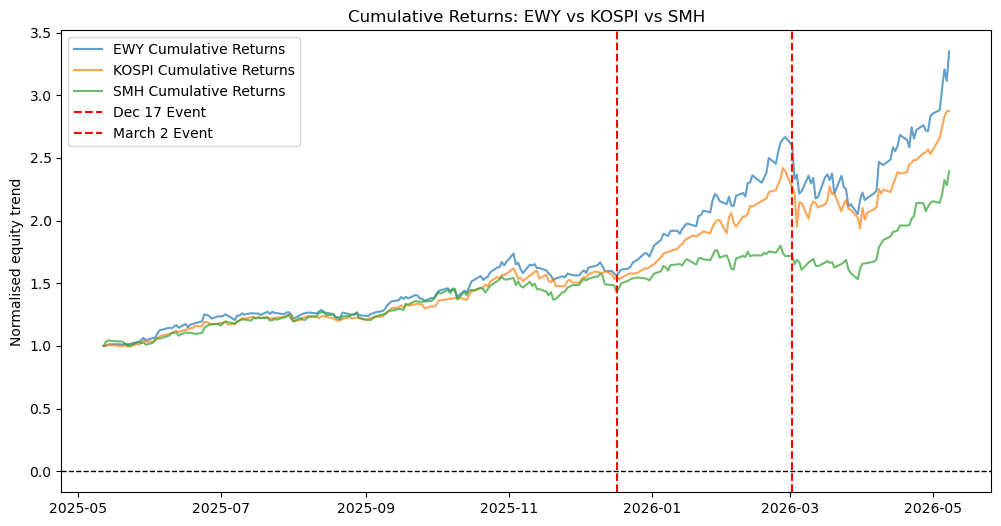

In [13]:
plt.figure(figsize=(12, 6))
plt.plot(EWY_data.index, EWY_data['Cumulative Returns'], label='EWY Cumulative Returns', alpha=0.7)
plt.plot(KOSPI_data.index, KOSPI_data['Cumulative Returns'], label='KOSPI Cumulative Returns', alpha=0.7)
plt.plot(SMH_data.index, SMH_data['Cumulative Returns'], label='SMH Cumulative Returns', alpha=0.7)

# Price trend started diverging after this date
plt.axvline(x=pd.to_datetime('2025-12-17'), color='red', linestyle='--', lw=1.5, label='Dec 17 Event')

# South Korea Samiljeol independence day holiday
plt.axvline(x=pd.to_datetime('2026-03-02'), color='red', linestyle='--', lw=1.5, label='March 2 Event')

plt.axhline(0, color='black', lw=1, ls='--') # Add a horizontal line at 0
plt.title('Cumulative Returns: EWY vs KOSPI vs SMH')
plt.ylabel('Normalised equity trend')
plt.legend()
plt.show()

Correlation (R): 0.2157
R-squared: 0.0465
Beta (Slope): 0.2373
Alpha (Intercept): 0.0043


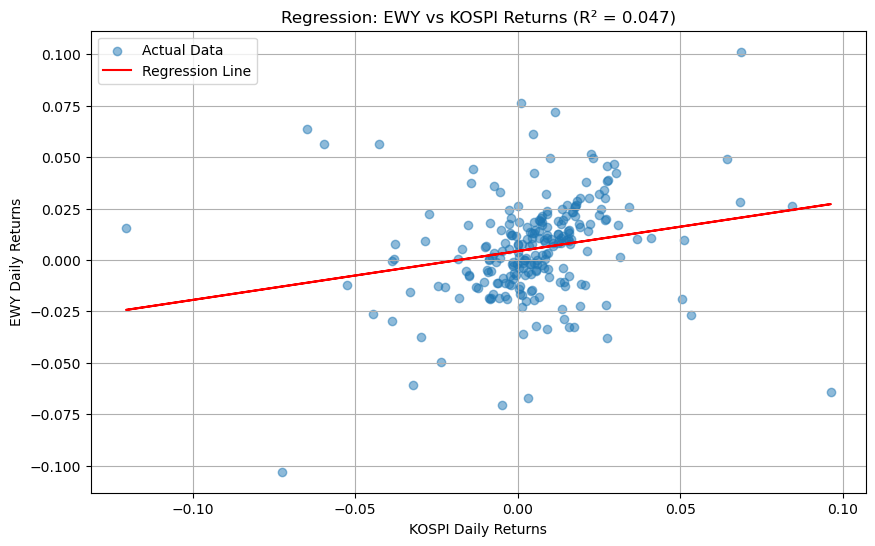

In [14]:
### Without KRW
import scipy.stats as stats

# Align data and remove the first row (NaN from pct_change)
combined_df = pd.concat([KOSPI_data['Returns'], EWY_data['Returns']], axis=1).dropna()
combined_df.columns = ['KOSPI', 'EWY']

slope, intercept, r_value, p_value, std_err = stats.linregress(combined_df['KOSPI'], combined_df['EWY'])

r_squared = r_value**2

print(f"Correlation (R): {r_value:.4f}")
print(f"R-squared: {r_squared:.4f}")
print(f"Beta (Slope): {slope:.4f}")
print(f"Alpha (Intercept): {intercept:.4f}")

plt.figure(figsize=(10, 6))
plt.scatter(combined_df['KOSPI'], combined_df['EWY'], alpha=0.5, label='Actual Data')
plt.plot(combined_df['KOSPI'], intercept + slope * combined_df['KOSPI'], color='red', label='Regression Line')

plt.title(f'Regression: EWY vs KOSPI Returns (R² = {r_squared:.3f})')
plt.xlabel('KOSPI Daily Returns')
plt.ylabel('EWY Daily Returns')
plt.legend()
plt.grid(True)
plt.show()

                            OLS Regression Results                            
Dep. Variable:                    EWY   R-squared:                       0.159
Model:                            OLS   Adj. R-squared:                  0.152
Method:                 Least Squares   F-statistic:                     21.93
Date:                Wed, 13 May 2026   Prob (F-statistic):           1.89e-09
Time:                        05:05:11   Log-Likelihood:                 558.09
No. Observations:                 235   AIC:                            -1110.
Df Residuals:                     232   BIC:                            -1100.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0034      0.002      2.225      0.0

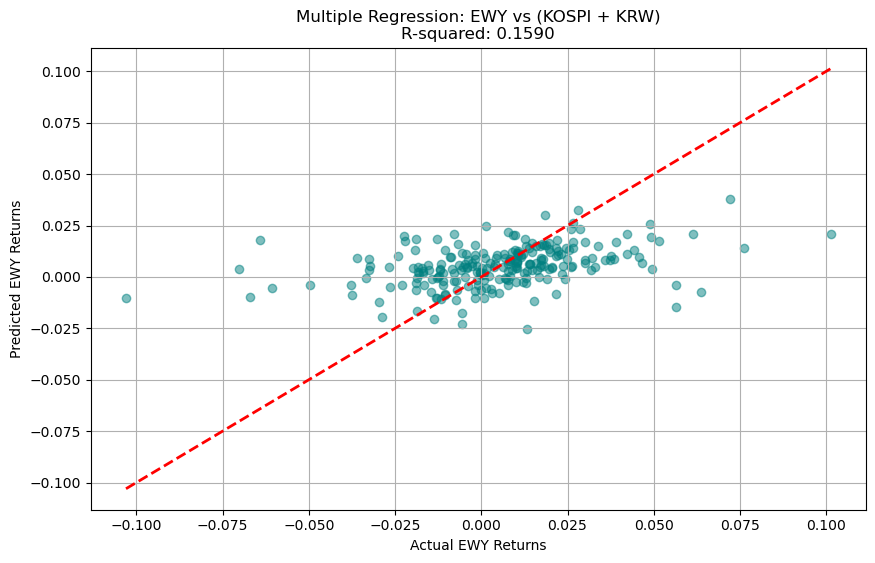

In [15]:
### Adding KRW to the regression

combined_df = pd.concat([KOSPI_data['Returns'], EWY_data['Returns'], KRW_data['Returns']], axis=1).dropna()
combined_df.columns = ['KOSPI', 'EWY', 'KRW']

y = combined_df['EWY']
X = combined_df[['KOSPI', 'KRW']]

# Statsmodels doesn't include an intercept by default
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

combined_df['Predicted_EWY'] = model.predict(X)

plt.figure(figsize=(10, 6))
plt.scatter(combined_df['EWY'], combined_df['Predicted_EWY'], alpha=0.5, color='teal')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2, linestyle='--') # 45-degree line

plt.title(f'Multiple Regression: EWY vs (KOSPI + KRW)\nR-squared: {model.rsquared:.4f}')
plt.xlabel('Actual EWY Returns')
plt.ylabel('Predicted EWY Returns')
plt.grid(True)
plt.show()

**Insights from data analyses of daily returns from full series**

- Poor overall R-sq of 0.05
- Adding effect of FX as a predictor improves R-sq to 0.16 (see if FX fluctuations can help explain some of the variation in EWY that is not explained by KOSPI returns)
- At a glance, there appears to be low correlation between daily returns of EWY and KOSPI in the overall time series. The next step is to split the time series by several potentially key dates to see if any stronger correlation can be detected.

#### Date 1: Divergence

In [18]:
split_date = dt.date(2025,12,17)

EWY_before = EWY_data[EWY_data.index < pd.Timestamp(split_date)].copy()
EWY_after = EWY_data[EWY_data.index >= pd.Timestamp(split_date)].copy()

KOSPI_before = KOSPI_data[KOSPI_data.index < pd.Timestamp(split_date)].copy()
KOSPI_after = KOSPI_data[KOSPI_data.index >= pd.Timestamp(split_date)].copy()

KRW_before = KRW_data[KRW_data.index < pd.Timestamp(split_date)].copy()
KRW_after = KRW_data[KRW_data.index >= pd.Timestamp(split_date)].copy()

for dataframe in [EWY_before, EWY_after, KOSPI_before, KOSPI_after, KRW_before, KRW_after]:
    setup_returns(dataframe)

                            OLS Regression Results                            
Dep. Variable:                    EWY   R-squared:                       0.336
Model:                            OLS   Adj. R-squared:                  0.327
Method:                 Least Squares   F-statistic:                     35.50
Date:                Wed, 13 May 2026   Prob (F-statistic):           3.38e-13
Time:                        05:05:11   Log-Likelihood:                 412.59
No. Observations:                 143   AIC:                            -819.2
Df Residuals:                     140   BIC:                            -810.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0010      0.001      0.821      0.4

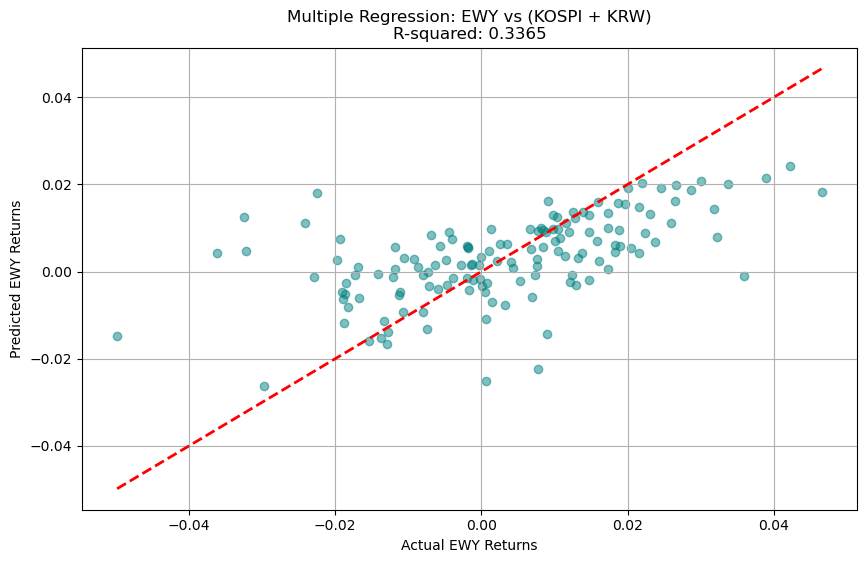

In [19]:
combined_df = pd.concat([KOSPI_before['Returns'], EWY_before['Returns'], KRW_before['Returns']], axis=1).dropna()
combined_df.columns = ['KOSPI', 'EWY', 'KRW']

y = combined_df['EWY']
X = combined_df[['KOSPI', 'KRW']]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

combined_df['Predicted_EWY'] = model.predict(X)

plt.figure(figsize=(10, 6))
plt.scatter(combined_df['EWY'], combined_df['Predicted_EWY'], alpha=0.5, color='teal')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2, linestyle='--') # 45-degree line

plt.title(f'Multiple Regression: EWY vs (KOSPI + KRW)\nR-squared: {model.rsquared:.4f}')
plt.xlabel('Actual EWY Returns')
plt.ylabel('Predicted EWY Returns')
plt.grid(True)
plt.show()

                            OLS Regression Results                            
Dep. Variable:                    EWY   R-squared:                       0.167
Model:                            OLS   Adj. R-squared:                  0.148
Method:                 Least Squares   F-statistic:                     8.814
Date:                Wed, 13 May 2026   Prob (F-statistic):           0.000324
Time:                        05:05:11   Log-Likelihood:                 189.05
No. Observations:                  91   AIC:                            -372.1
Df Residuals:                      88   BIC:                            -364.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0066      0.003      1.979      0.0

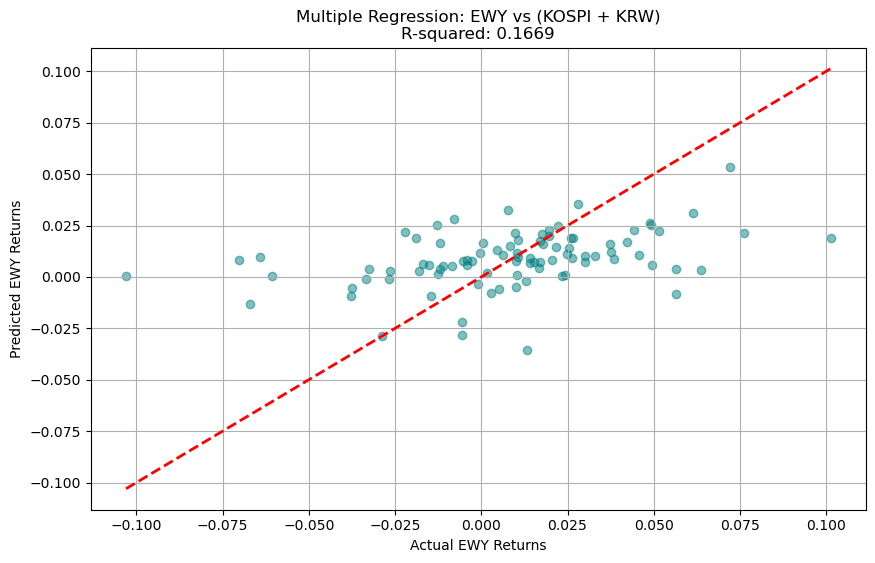

In [20]:
# 1. Align data and handle NaNs
combined_df = pd.concat([KOSPI_after['Returns'], EWY_after['Returns'], KRW_after['Returns']], axis=1).dropna()
combined_df.columns = ['KOSPI', 'EWY', 'KRW']

# 2. Define your variables
# y is what we want to explain (EWY)
# X contains our predictors (KOSPI and KRW)
y = combined_df['EWY']
X = combined_df[['KOSPI', 'KRW']]

# 3. Add a constant (Alpha/Intercept)
# Statsmodels doesn't include an intercept by default
X = sm.add_constant(X)

# 4. Fit the Multiple Linear Regression model
model = sm.OLS(y, X).fit()

# 5. Output Results
print(model.summary())

# 6. Visualization: Actual vs. Predicted
# (Since we have 2 predictors, we can't do a simple 2D line plot easily. 
# A common way to show fit is 'Actual vs Predicted')
combined_df['Predicted_EWY'] = model.predict(X)

plt.figure(figsize=(10, 6))
plt.scatter(combined_df['EWY'], combined_df['Predicted_EWY'], alpha=0.5, color='teal')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2, linestyle='--') # 45-degree line

plt.title(f'Multiple Regression: EWY vs (KOSPI + KRW)\nR-squared: {model.rsquared:.4f}')
plt.xlabel('Actual EWY Returns')
plt.ylabel('Predicted EWY Returns')
plt.grid(True)
plt.show()

In [21]:
# normally, if the KRW is decreasing (i.e. KRW=X is rallying), EWY holdings are worth fewer KRW, so EWY should decrease. The beta
# should thus be negative but it is positive
# therefore sanity check the fact that KRW=X is rallying together with EWY
print(combined_df[['EWY', 'KOSPI', 'KRW']].corr())

            EWY     KOSPI       KRW
EWY    1.000000  0.097345  0.291788
KOSPI  0.097345  1.000000 -0.509532
KRW    0.291788 -0.509532  1.000000


**Insights**

- R-sq between daily returns of EWY regressed on KOSPI and KRW before key date is low at 0.34, but higher than full period of 0.16
- R-sq after the key date is much lower at 0.17

#### Date 2: South Korea Market Holiday

In [24]:
split_date = dt.date(2026,3,2)

EWY_before = EWY_data[EWY_data.index < pd.Timestamp(split_date)].copy()
EWY_after = EWY_data[EWY_data.index >= pd.Timestamp(split_date)].copy()

KOSPI_before = KOSPI_data[KOSPI_data.index < pd.Timestamp(split_date)].copy()
KOSPI_after = KOSPI_data[KOSPI_data.index >= pd.Timestamp(split_date)].copy()

KRW_before = KRW_data[KRW_data.index < pd.Timestamp(split_date)].copy()
KRW_after = KRW_data[KRW_data.index >= pd.Timestamp(split_date)].copy()

for dataframe in [EWY_before, EWY_after, KOSPI_before, KOSPI_after, KRW_before, KRW_after]:
    setup_returns(dataframe)

                            OLS Regression Results                            
Dep. Variable:                    EWY   R-squared:                       0.274
Model:                            OLS   Adj. R-squared:                  0.267
Method:                 Least Squares   F-statistic:                     35.16
Date:                Wed, 13 May 2026   Prob (F-statistic):           1.12e-13
Time:                        05:05:12   Log-Likelihood:                 522.90
No. Observations:                 189   AIC:                            -1040.
Df Residuals:                     186   BIC:                            -1030.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0026      0.001      2.194      0.0

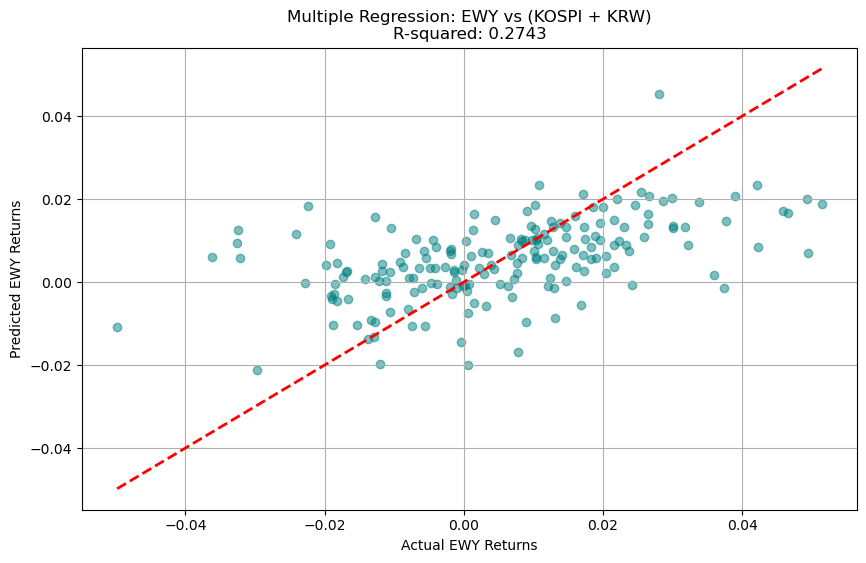

In [25]:
combined_df = pd.concat([KOSPI_before['Returns'], EWY_before['Returns'], KRW_before['Returns']], axis=1).dropna()
combined_df.columns = ['KOSPI', 'EWY', 'KRW']

y = combined_df['EWY']
X = combined_df[['KOSPI', 'KRW']]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

combined_df['Predicted_EWY'] = model.predict(X)

plt.figure(figsize=(10, 6))
plt.scatter(combined_df['EWY'], combined_df['Predicted_EWY'], alpha=0.5, color='teal')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2, linestyle='--') # 45-degree line

plt.title(f'Multiple Regression: EWY vs (KOSPI + KRW)\nR-squared: {model.rsquared:.4f}')
plt.xlabel('Actual EWY Returns')
plt.ylabel('Predicted EWY Returns')
plt.grid(True)
plt.show()

                            OLS Regression Results                            
Dep. Variable:                    EWY   R-squared:                       0.260
Model:                            OLS   Adj. R-squared:                  0.225
Method:                 Least Squares   F-statistic:                     7.383
Date:                Wed, 13 May 2026   Prob (F-statistic):            0.00179
Time:                        05:05:12   Log-Likelihood:                 88.613
No. Observations:                  45   AIC:                            -171.2
Df Residuals:                      42   BIC:                            -165.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0052      0.005      0.979      0.3

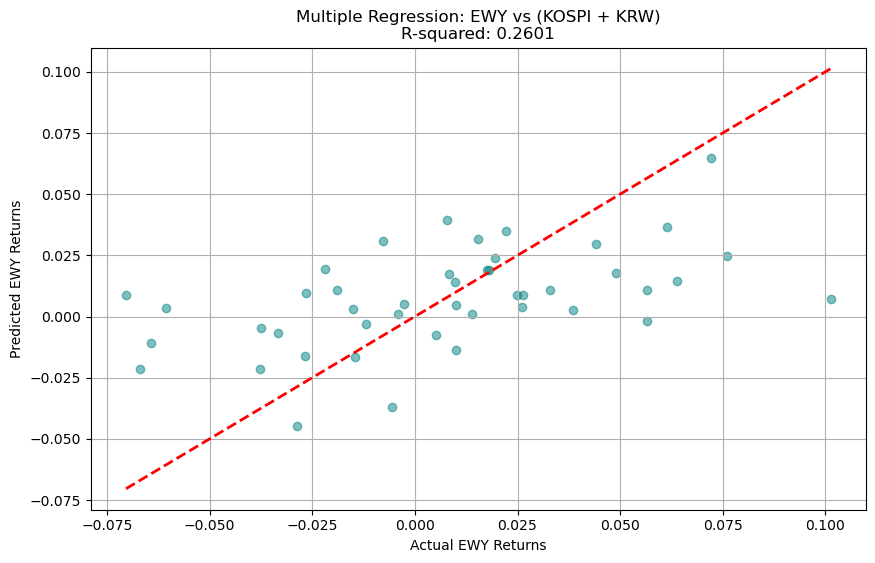

In [26]:
# 1. Align data and handle NaNs
combined_df = pd.concat([KOSPI_after['Returns'], EWY_after['Returns'], KRW_after['Returns']], axis=1).dropna()
combined_df.columns = ['KOSPI', 'EWY', 'KRW']

# 2. Define your variables
# y is what we want to explain (EWY)
# X contains our predictors (KOSPI and KRW)
y = combined_df['EWY']
X = combined_df[['KOSPI', 'KRW']]

# 3. Add a constant (Alpha/Intercept)
# Statsmodels doesn't include an intercept by default
X = sm.add_constant(X)

# 4. Fit the Multiple Linear Regression model
model = sm.OLS(y, X).fit()

# 5. Output Results
print(model.summary())

# 6. Visualization: Actual vs. Predicted
# (Since we have 2 predictors, we can't do a simple 2D line plot easily. 
# A common way to show fit is 'Actual vs Predicted')
combined_df['Predicted_EWY'] = model.predict(X)

plt.figure(figsize=(10, 6))
plt.scatter(combined_df['EWY'], combined_df['Predicted_EWY'], alpha=0.5, color='teal')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2, linestyle='--') # 45-degree line

plt.title(f'Multiple Regression: EWY vs (KOSPI + KRW)\nR-squared: {model.rsquared:.4f}')
plt.xlabel('Actual EWY Returns')
plt.ylabel('Predicted EWY Returns')
plt.grid(True)
plt.show()

**Insights**

- R-sq is now more even between both periods.
- R-sq between daily returns of EWY regressed on KOSPI and KRW before key date is still low at 0.27
- R-sq after the key date is slightly higher than previous key date analyses at 0.26

### Weekly data

#### Full period analyses

In [30]:
start_date = dt.date(2025,5,11)
end_date = dt.date(2026,5,10)
EWY_data = yf.download("EWY", start_date, end_date, auto_adjust = False)
KOSPI_data = yf.download("^KS11", start_date, end_date, auto_adjust = False)
KRW_data = yf.download("KRW=X", start_date, end_date, auto_adjust = False)
SMH_data = yf.download("SMH", start_date, end_date, auto_adjust = False)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [31]:
EWY_data = EWY_data[['Adj Close', 'Volume']].copy()
KOSPI_data = KOSPI_data[['Adj Close', 'Volume']].copy()
SMH_data = SMH_data[['Adj Close', 'Volume']].copy()
KRW_data = KRW_data[['Adj Close', 'Volume']].copy()

EWY_data = setup_weekly_returns(EWY_data)
KOSPI_data = setup_weekly_returns(KOSPI_data)
KRW_data = setup_weekly_returns(KRW_data)
SMH_data = setup_weekly_returns(SMH_data)

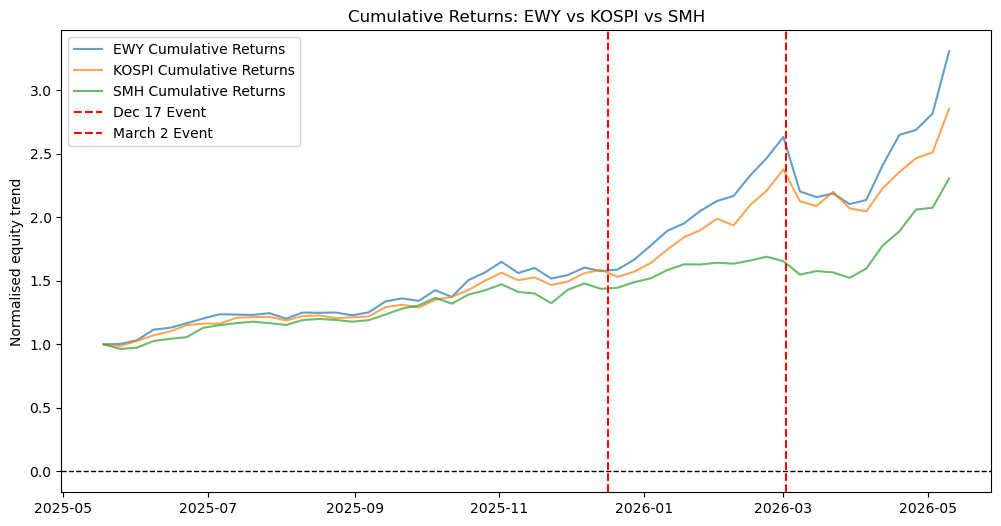

In [32]:
plt.figure(figsize=(12, 6))
plt.plot(EWY_data.index, EWY_data['Cumulative Returns'], label='EWY Cumulative Returns', alpha=0.7)
plt.plot(KOSPI_data.index, KOSPI_data['Cumulative Returns'], label='KOSPI Cumulative Returns', alpha=0.7)
plt.plot(SMH_data.index, SMH_data['Cumulative Returns'], label='SMH Cumulative Returns', alpha=0.7)

# Some divergence I dont know
plt.axvline(x=pd.to_datetime('2025-12-17'), color='red', linestyle='--', lw=1.5, label='Dec 17 Event')

# south korea independence day holiday
plt.axvline(x=pd.to_datetime('2026-03-02'), color='red', linestyle='--', lw=1.5, label='March 2 Event')

plt.axhline(0, color='black', lw=1, ls='--') # Add a horizontal line at 0
plt.title('Cumulative Returns: EWY vs KOSPI vs SMH')
plt.ylabel('Normalised equity trend')
plt.legend()
plt.show()

                            OLS Regression Results                            
Dep. Variable:                    EWY   R-squared:                       0.774
Model:                            OLS   Adj. R-squared:                  0.765
Method:                 Least Squares   F-statistic:                     82.43
Date:                Wed, 13 May 2026   Prob (F-statistic):           2.99e-16
Time:                        05:05:12   Log-Likelihood:                 117.38
No. Observations:                  51   AIC:                            -228.8
Df Residuals:                      48   BIC:                            -223.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0046      0.004      1.099      0.2

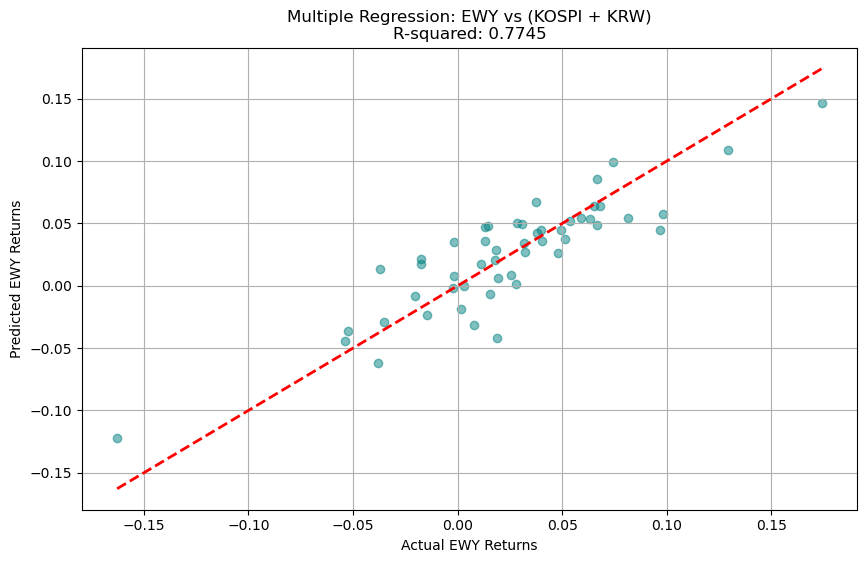

In [33]:
combined_df = pd.concat([KOSPI_data['Returns'], EWY_data['Returns'], KRW_data['Returns']], axis=1).dropna()
combined_df.columns = ['KOSPI', 'EWY', 'KRW']

y = combined_df['EWY']
X = combined_df[['KOSPI', 'KRW']]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

combined_df['Predicted_EWY'] = model.predict(X)

plt.figure(figsize=(10, 6))
plt.scatter(combined_df['EWY'], combined_df['Predicted_EWY'], alpha=0.5, color='teal')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2, linestyle='--') # 45-degree line

plt.title(f'Multiple Regression: EWY vs (KOSPI + KRW)\nR-squared: {model.rsquared:.4f}')
plt.xlabel('Actual EWY Returns')
plt.ylabel('Predicted EWY Returns')
plt.grid(True)
plt.show()

**Insights**

- R-sq is vastly improved, implying that the relationship between daily returns is noisy, which can be smoothed out by sampling weekly data instead.
- The R-sq of weekly returns is 0.77, which indicates a strong linear relationship between weekly returns of EWY and KOSPI.

#### Date 1: Divergence

In [36]:
split_date = dt.date(2025,12,17)

EWY_before = EWY_data[EWY_data.index < pd.Timestamp(split_date)].copy()
EWY_after = EWY_data[EWY_data.index >= pd.Timestamp(split_date)].copy()

KOSPI_before = KOSPI_data[KOSPI_data.index < pd.Timestamp(split_date)].copy()
KOSPI_after = KOSPI_data[KOSPI_data.index >= pd.Timestamp(split_date)].copy()

KRW_before = KRW_data[KRW_data.index < pd.Timestamp(split_date)].copy()
KRW_after = KRW_data[KRW_data.index >= pd.Timestamp(split_date)].copy()

for dataframe in [EWY_before, EWY_after, KOSPI_before, KOSPI_after, KRW_before, KRW_after]:
    setup_weekly_returns(dataframe)

                            OLS Regression Results                            
Dep. Variable:                    EWY   R-squared:                       0.663
Model:                            OLS   Adj. R-squared:                  0.638
Method:                 Least Squares   F-statistic:                     26.60
Date:                Wed, 13 May 2026   Prob (F-statistic):           4.14e-07
Time:                        05:05:12   Log-Likelihood:                 73.371
No. Observations:                  30   AIC:                            -140.7
Df Residuals:                      27   BIC:                            -136.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0015      0.005      0.315      0.7

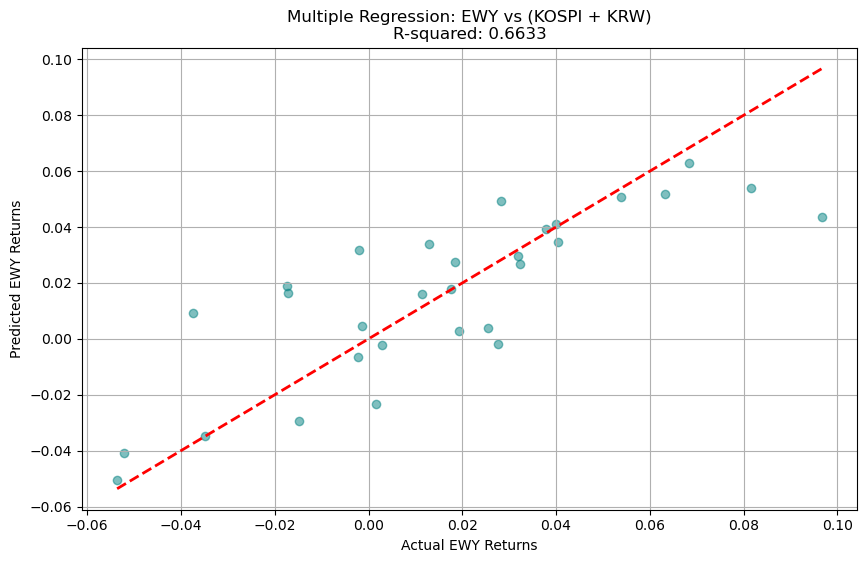

In [37]:
combined_df = pd.concat([KOSPI_before['Returns'], EWY_before['Returns'], KRW_before['Returns']], axis=1).dropna()
combined_df.columns = ['KOSPI', 'EWY', 'KRW']

y = combined_df['EWY']
X = combined_df[['KOSPI', 'KRW']]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

combined_df['Predicted_EWY'] = model.predict(X)

plt.figure(figsize=(10, 6))
plt.scatter(combined_df['EWY'], combined_df['Predicted_EWY'], alpha=0.5, color='teal')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2, linestyle='--') # 45-degree line

plt.title(f'Multiple Regression: EWY vs (KOSPI + KRW)\nR-squared: {model.rsquared:.4f}')
plt.xlabel('Actual EWY Returns')
plt.ylabel('Predicted EWY Returns')
plt.grid(True)
plt.show()

                            OLS Regression Results                            
Dep. Variable:                    EWY   R-squared:                       0.818
Model:                            OLS   Adj. R-squared:                  0.797
Method:                 Least Squares   F-statistic:                     40.34
Date:                Wed, 13 May 2026   Prob (F-statistic):           2.23e-07
Time:                        05:05:13   Log-Likelihood:                 45.617
No. Observations:                  21   AIC:                            -85.23
Df Residuals:                      18   BIC:                            -82.10
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0091      0.008      1.154      0.2

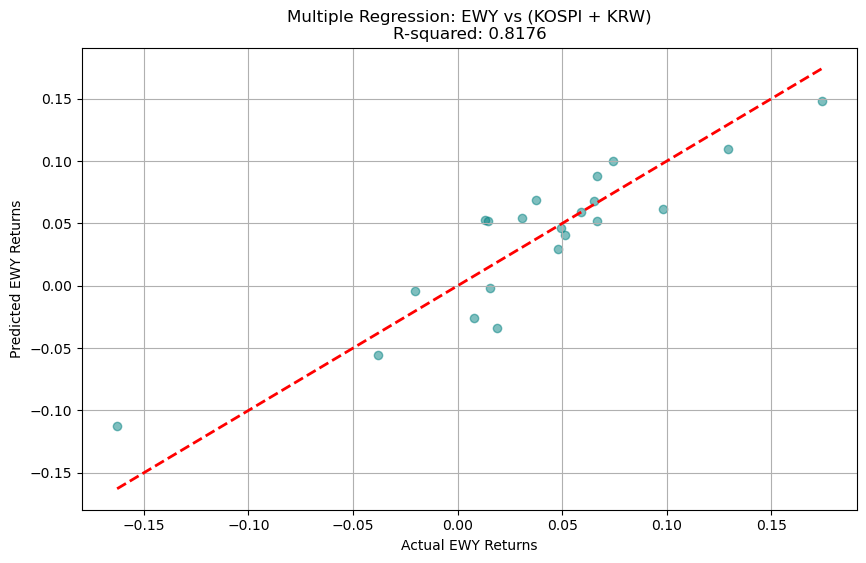

In [38]:
combined_df = pd.concat([KOSPI_after['Returns'], EWY_after['Returns'], KRW_after['Returns']], axis=1).dropna()
combined_df.columns = ['KOSPI', 'EWY', 'KRW']

y = combined_df['EWY']
X = combined_df[['KOSPI', 'KRW']]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

combined_df['Predicted_EWY'] = model.predict(X)

plt.figure(figsize=(10, 6))
plt.scatter(combined_df['EWY'], combined_df['Predicted_EWY'], alpha=0.5, color='teal')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2, linestyle='--') # 45-degree line

plt.title(f'Multiple Regression: EWY vs (KOSPI + KRW)\nR-squared: {model.rsquared:.4f}')
plt.xlabel('Actual EWY Returns')
plt.ylabel('Predicted EWY Returns')
plt.grid(True)
plt.show()

**Insights**

- R-sq on the before set is higher than in the overall time-series (0.82 vs 0.77)
- R-sq on weekly data in the after set is much higher than that of the before set (0.82 vs 0.66)

#### Date 2: South Korea market holiday

In [41]:
split_date = dt.date(2026,3,2)

EWY_before = EWY_data[EWY_data.index < pd.Timestamp(split_date)].copy()
EWY_after = EWY_data[EWY_data.index >= pd.Timestamp(split_date)].copy()

KOSPI_before = KOSPI_data[KOSPI_data.index < pd.Timestamp(split_date)].copy()
KOSPI_after = KOSPI_data[KOSPI_data.index >= pd.Timestamp(split_date)].copy()

KRW_before = KRW_data[KRW_data.index < pd.Timestamp(split_date)].copy()
KRW_after = KRW_data[KRW_data.index >= pd.Timestamp(split_date)].copy()

for dataframe in [EWY_before, EWY_after, KOSPI_before, KOSPI_after, KRW_before, KRW_after]:
    setup_weekly_returns(dataframe)

                            OLS Regression Results                            
Dep. Variable:                    EWY   R-squared:                       0.619
Model:                            OLS   Adj. R-squared:                  0.599
Method:                 Least Squares   F-statistic:                     30.86
Date:                Wed, 13 May 2026   Prob (F-statistic):           1.10e-08
Time:                        05:05:13   Log-Likelihood:                 98.283
No. Observations:                  41   AIC:                            -190.6
Df Residuals:                      38   BIC:                            -185.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0066      0.005      1.464      0.1

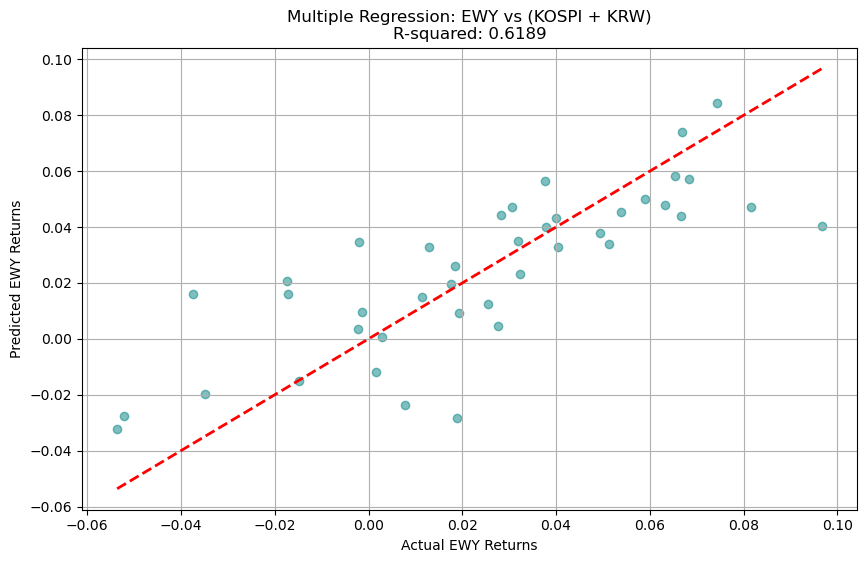

In [42]:
combined_df = pd.concat([KOSPI_before['Returns'], EWY_before['Returns'], KRW_before['Returns']], axis=1).dropna()
combined_df.columns = ['KOSPI', 'EWY', 'KRW']

y = combined_df['EWY']
X = combined_df[['KOSPI', 'KRW']]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

combined_df['Predicted_EWY'] = model.predict(X)

plt.figure(figsize=(10, 6))
plt.scatter(combined_df['EWY'], combined_df['Predicted_EWY'], alpha=0.5, color='teal')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2, linestyle='--') # 45-degree line

plt.title(f'Multiple Regression: EWY vs (KOSPI + KRW)\nR-squared: {model.rsquared:.4f}')
plt.xlabel('Actual EWY Returns')
plt.ylabel('Predicted EWY Returns')
plt.grid(True)
plt.show()

                            OLS Regression Results                            
Dep. Variable:                    EWY   R-squared:                       0.927
Model:                            OLS   Adj. R-squared:                  0.907
Method:                 Least Squares   F-statistic:                     44.76
Date:                Wed, 13 May 2026   Prob (F-statistic):           0.000103
Time:                        05:05:13   Log-Likelihood:                 23.039
No. Observations:                  10   AIC:                            -40.08
Df Residuals:                       7   BIC:                            -39.17
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0111      0.011      1.045      0.3

C:\Users\Raymon\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=10
  res = hypotest_fun_out(*samples, **kwds)


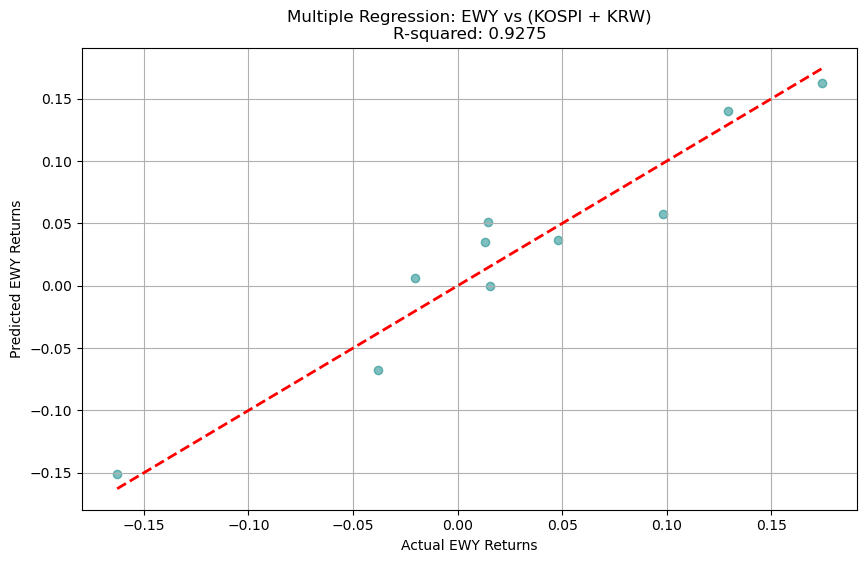

In [43]:
combined_df = pd.concat([KOSPI_after['Returns'], EWY_after['Returns'], KRW_after['Returns']], axis=1).dropna()
combined_df.columns = ['KOSPI', 'EWY', 'KRW']

y = combined_df['EWY']
X = combined_df[['KOSPI', 'KRW']]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

combined_df['Predicted_EWY'] = model.predict(X)

plt.figure(figsize=(10, 6))
plt.scatter(combined_df['EWY'], combined_df['Predicted_EWY'], alpha=0.5, color='teal')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2, linestyle='--') # 45-degree line

plt.title(f'Multiple Regression: EWY vs (KOSPI + KRW)\nR-squared: {model.rsquared:.4f}')
plt.xlabel('Actual EWY Returns')
plt.ylabel('Predicted EWY Returns')
plt.grid(True)
plt.show()

**Insights**

- The R-sq in the second period is much higher than the R-sq in the first. But it is less reliable, as there are few datapoints to construct a representative line of best fit.

### NAV reconstruction and analysis

Reconstructing the NAV of EWY could be helpful in explaining the outperformance of EWY on the KOSPI. The thought process is that demand for ETFs can cause the ETF price to diverge above the NAV of the constituent equities.

In [81]:
EWY_ETF_stats = pd.read_excel(r'EWY data.xlsx')
start_date = dt.date(2025,5,11)
end_date = dt.date(2026,5,10)

EWY_data = yf.download("EWY", start_date, end_date, auto_adjust = False)
EWY_data = EWY_data[['Adj Close', 'Volume']].copy()

EWY_units = 126150000

[*********************100%***********************]  1 of 1 completed


C:\Users\Raymon\AppData\Local\Temp\ipykernel_10436\1675343563.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_prices = yf.download(all_data_tickers, start="2025-05-11", end="2026-05-11")['Close']
[*********************100%***********************]  80 of 80 completed


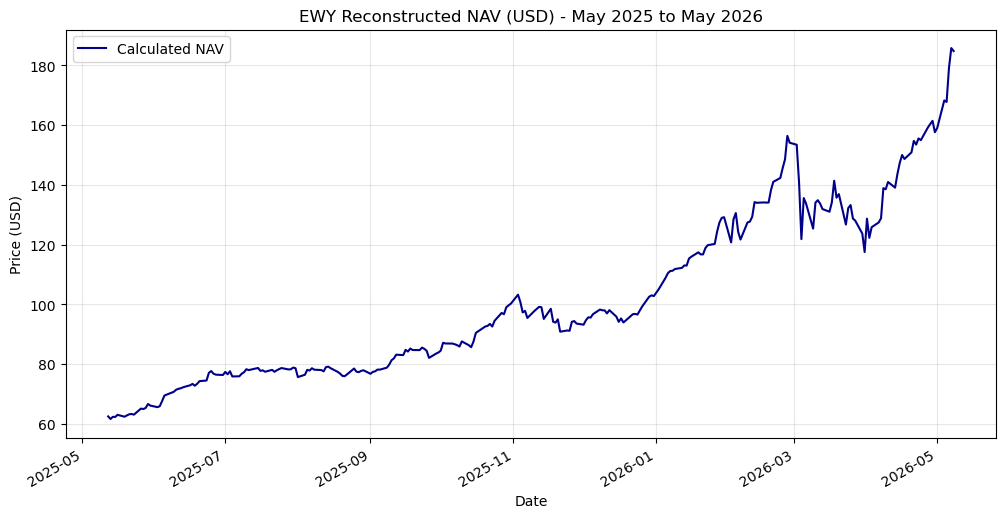

In [83]:
df_cleaned = EWY_ETF_stats.iloc[:-10].drop(index=[79, 46]).copy()

is_equity = df_cleaned['Asset Class'].str.contains('Equity', case=False, na=False)

equity_holdings = df_cleaned[is_equity].copy()
non_equity_holdings = df_cleaned[~is_equity].copy()

total_cash_krw = non_equity_holdings['Quantity'].sum()

equity_tickers = [str(t).zfill(6) + ".KS" for t in equity_holdings['Ticker']]
all_data_tickers = equity_tickers + ["USDKRW=X"]

raw_prices = yf.download(all_data_tickers, start="2025-05-11", end="2026-05-11")['Close']

raw_prices = raw_prices.ffill()

qty_map = equity_holdings.set_index(equity_holdings['Ticker'].astype(str).str.zfill(6) + ".KS")['Quantity']
daily_equity_krw = raw_prices[equity_tickers].multiply(qty_map, axis=1).sum(axis=1)

total_fund_usd = (daily_equity_krw + total_cash_krw) / raw_prices['USDKRW=X']
final_nav_df = pd.DataFrame()
final_nav_df['Reconstructed_NAV'] = total_fund_usd.dropna() / EWY_units

# Plotting Comparison
final_nav_df['Reconstructed_NAV'].plot(figsize=(12, 6), label='Calculated NAV', color='darkblue')
plt.title('EWY Reconstructed NAV (USD) - May 2025 to May 2026')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

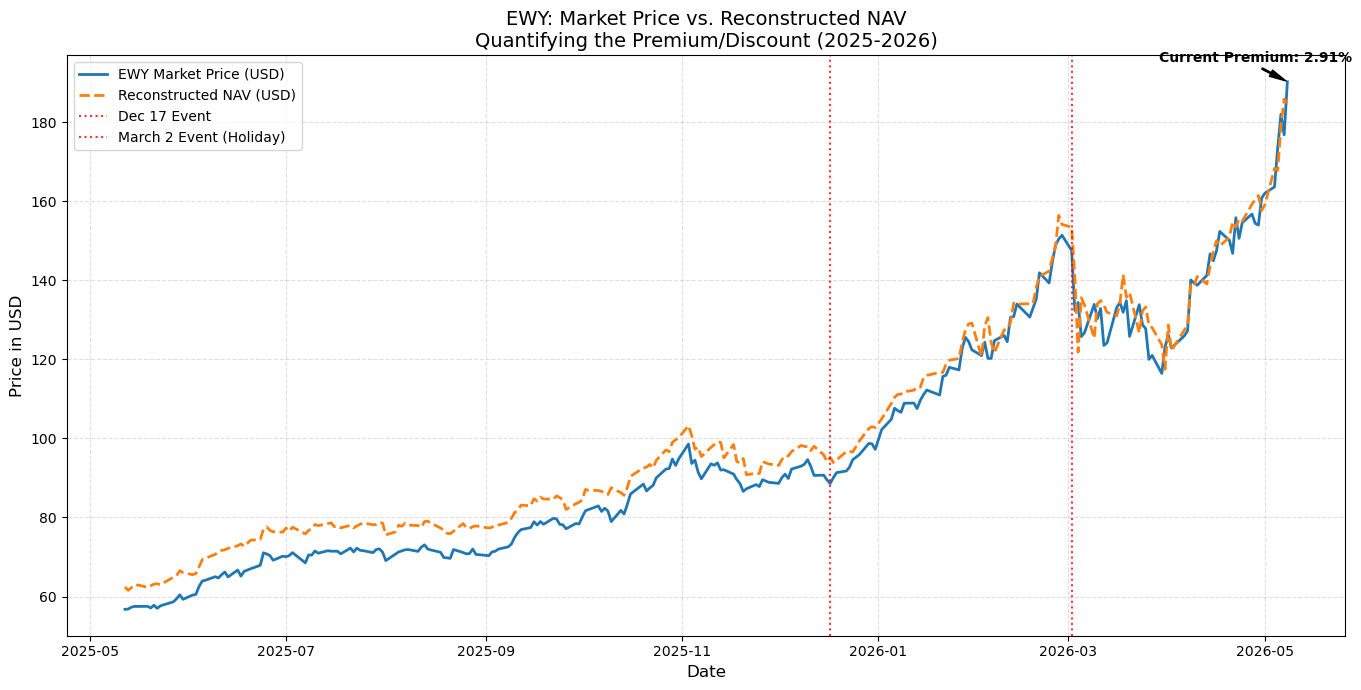

In [85]:
comparison_df = pd.concat([
    final_nav_df['Reconstructed_NAV'], 
    EWY_data['Adj Close']
], axis=1).dropna()

comparison_df.columns = ['Reconstructed_NAV', 'Market_Price']

plt.figure(figsize=(14, 7))

plt.plot(comparison_df.index, comparison_df['Market_Price'], 
         label='EWY Market Price (USD)', color='#1f77b4', linewidth=2)
plt.plot(comparison_df.index, comparison_df['Reconstructed_NAV'], 
         label='Reconstructed NAV (USD)', color='#ff7f0e', linewidth=2, linestyle='--')

plt.axvline(pd.to_datetime('2025-12-17'), color='red', linestyle=':', alpha=0.8, label='Dec 17 Event')
plt.axvline(pd.to_datetime('2026-03-02'), color='red', linestyle=':', alpha=0.8, label='March 2 Event (Holiday)')

plt.title('EWY: Market Price vs. Reconstructed NAV\nQuantifying the Premium/Discount (2025-2026)', fontsize=14)
plt.ylabel('Price in USD', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, which='both', linestyle='--', alpha=0.4)

latest = comparison_df.iloc[-1]
premium = (latest['Market_Price'] - latest['Reconstructed_NAV']) / latest['Reconstructed_NAV'] * 100

plt.annotate(f'Current Premium: {premium:.2f}%', 
             xy=(comparison_df.index[-1], latest['Market_Price']),
             xytext=(comparison_df.index[-1] - pd.Timedelta(days=40), latest['Market_Price'] + 5),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
             fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

**Insights**

- EWY appears to have trailed its NAV early on in the period assessed. The gap reduced further into the period.
- The final premium of EWY over its constituents is 2.91%, which while significant, does not mean anything on its own, as towards the final measurement, the NAV and ETF price crossed each other multiple times, indicating that the 2.91% premium could be a momentary fluctuation.

### Results

- R-sq of weekly return data between EWY and KOSPI is much higher than daily returns.
- Daily return R-sq is low, while weekly return R-sq is much higher. I have thus devised the below trading strategy to exploit this relationship.

### Strategy

**Exploitation of high correlation in weekly returns to form a pairs trading strategy based on the spread in midweek week-to-date returns.** 

- Use the low daily correlations and high weekly correlations to define a long short strategy.
- Calculate week to date (WTD) returns for EWY and KOSPI.
- Calculate the spread between WTD returns on Wednesday as EWY_WTD_Returns - KOSPI_WTD_Returns  
- Use the spread to form a signal on Thursday and Friday.
    - If the spread > threshold: EWY is overvalued or KOSPI is undervalued. Short EWY, Long KOSPI at their respective Thursday Opens. Close at their respective Friday Closes.
    - If the spread < threshold: KOSPI is overvalued or EWY is undervalued. Short KOSPI, Long EWY at their respective Thursday Opens. Close at their respective Friday Closes.
- This strategy makes a bet on the spread to mean revert by the end of the week in terms of direction. The aim is not to beat buy-and-hold, but to minimise max drawdown and generate a higher sharpe, as trending risk-on-assets are prone to sharp corrections.

**Possible additions**:

- Stop loss: If the spread widens on Thursday, the strategy will incur losses. If the losses exceed a particular threshold, assume the spread will not close and exit the trade by EOD Thursday.
- VIX filter: Consider avoiding volatility by not trading when the VIX exceeds the long run average of 20.

In [88]:
start_date = dt.date(2025,5,11)
end_date = dt.date(2026,5,10)
EWY_data = yf.download("EWY", start_date, end_date, auto_adjust = False)
KOSPI_data = yf.download("^KS11", start_date, end_date, auto_adjust = False)
KRW_data = yf.download("KRW=X", start_date, end_date, auto_adjust = False)
VIX_data = yf.download("^VIX", start_date, end_date, auto_adjust = False)

EWY_data = setup_returns(EWY_data)
KOSPI_data = setup_returns(KOSPI_data)
KRW_data = setup_returns(KRW_data)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


#### Full period analyses

The strategy will be implemented via 2 functions.

- A baseline function implementing the long-short strategy
- The original strategy augmented with stop-loss functionality to exit the trade by Thursday EOD and stop trading for the week

In [91]:
# Baseline long short theses
def backtest_midweek_convergence(EWY_data, KOSPI_data, KRW_data, threshold = 0.01):
    """
    EWY_data, KOSPI_data, KRW_data: DFs with 'Returns' and DatetimeIndex.
    Logic: Calculate WTD spread on Wed EOD, trade Thu/Fri.
    """
    # Align and combine data
    df = pd.DataFrame({
        'EWY': EWY_data['Returns'],
        'KOSPI': KOSPI_data['Returns'],
        'KRW': KRW_data['Returns']
    }).dropna()
    
    # Adjust KOSPI to USD terms (to match EWY)
    df['KOSPI_USD'] = (1 + df['KOSPI']) * (1 + df['KRW']) - 1
    
    # Identify Day of Week (0=Mon, 2=Wed, 3=Thu, 4=Fri)
    df['Day'] = df.index.dayofweek
    df['Week_ID'] = df.index.isocalendar().week
    df['Year_ID'] = df.index.isocalendar().year

    # Calculate Week-to-Date (WTD) Returns
    # group by year/week and calculate cumulative return
    df['EWY_WTD'] = df.groupby(['Year_ID', 'Week_ID'])['EWY'].transform(lambda x: (1 + x).cumprod() - 1)
    df['KOSPI_WTD'] = df.groupby(['Year_ID', 'Week_ID'])['KOSPI_USD'].transform(lambda x: (1 + x).cumprod() - 1)
    
    # Calculate the Midweek Spread (Wednesday EOD)
    df['Spread_WTD'] = df['EWY_WTD'] - df['KOSPI_WTD']
    
    # Generate Trade Signals
    df['Signal'] = 0
      
    # Extract Wednesday values and shift them to Thursday/Friday
    wed_signals = df[df['Day'] == 2][['Spread_WTD']]
    
    for idx, row in wed_signals.iterrows():
        # Target the following Thursday and Friday
        mask = (df['Week_ID'] == df.loc[idx, 'Week_ID']) & \
               (df['Year_ID'] == df.loc[idx, 'Year_ID']) & \
               (df['Day'] >= 3)
        
        if row['Spread_WTD'] > threshold:
            df.loc[mask, 'Signal'] = -1  # EWY too high -> Short EWY / Long KOSPI
        elif row['Spread_WTD'] < -threshold:
            df.loc[mask, 'Signal'] = 1   # EWY too low -> Long EWY / Short KOSPI

    # Calculate Strategy Returns
    df['Strategy_Ret'] = df['Signal'] * (df['EWY'] - df['KOSPI_USD'])
    df['Cumu_Strategy_Ret'] = (1 + df['Strategy_Ret']).cumprod()

    df['Buy_and_Hold_KOSPI'] = (1 + df['KOSPI_USD']).cumprod()
    df['Buy_and_Hold_EWY'] = (1 + df['EWY']).cumprod()
    
    return df

# Usage
results_df = backtest_midweek_convergence(EWY_data, KOSPI_data, KRW_data, 0.01)

In [92]:
def get_performance_metrics(series, name):
    # Filter for non-zero days to get actual trading stats
    # For B&H, this is almost every day. For strategy, it's 27.7% of days.
    active_returns = series[series != 0]
    
    wins = active_returns[active_returns > 0]
    losses = active_returns[active_returns < 0]
    
    win_rate = len(wins) / len(active_returns) if len(active_returns) > 0 else 0
    
    # Profit Factor = Sum of Wins / Abs(Sum of Losses)
    profit_factor = wins.sum() / abs(losses.sum()) if abs(losses.sum()) > 0 else 0
    
    return {
        'Asset': name,
        'Win Rate': win_rate,
        'Profit Factor': profit_factor,
        'Avg Win': wins.mean(),
        'Avg Loss': losses.mean(),
        'Total Trades': len(active_returns)
    }

metrics = [
    get_performance_metrics(results_df['EWY'], 'EWY (B&H)'),
    get_performance_metrics(results_df['KOSPI_USD'], 'KOSPI (B&H)'),
    get_performance_metrics(results_df['Strategy_Ret'], 'Strategy')
]

# Create DataFrame
comparison_df = pd.DataFrame(metrics).set_index('Asset')
comparison_df_t = comparison_df.T

display(comparison_df_t)

Asset,EWY (B&H),KOSPI (B&H),Strategy
Win Rate,0.602564,0.642553,0.600000
Profit Factor,1.818919,1.899899,2.156009
Avg Win,0.019904,0.015607,0.021575
Avg Loss,-0.016591,-0.014767,-0.015010
Total Trades,234.000000,235.000000,65.000000


In [93]:
assets = {
    'EWY': results_df['EWY'],
    'KOSPI_USD': results_df['KOSPI_USD'],
    'Strategy': results_df['Strategy_Ret']
}

stats = {}

for name, series in assets.items():
    stats[name] = {
        'Daily Std Dev': series.std(),
        'Ann. Std Dev': series.std() * np.sqrt(252),
        'Max Drawdown': calc_max_dd(series),
        'Sharpe Ratio': calc_sharpe(series),
        'Sortino Ratio': calculate_sortino_ratio(series, rf=0, target_return=0)
    }

summary_df = pd.DataFrame(stats)

display(summary_df)

,EWY,KOSPI_USD,Strategy
Daily Std Dev,0.024598,0.021056,0.015255
Ann. Std Dev,0.390482,0.334246,0.242169
Max Drawdown,-0.210858,-0.164267,-0.094443
Sharpe Ratio,3.469885,3.581211,1.997744
Sortino Ratio,3.574888,3.383159,1.534627


**Insights**

Over the full period, without a stop loss...

- The strategy undertakes lower non-systematic risk than EWY and the KOSPI
- The strategy also has a lower max drawdown than EWY and the KOSPI, with max drawdown of -9.4%
- The strategy has comparable win rate to buy and hold of EWY and the KOSPI
- The strategy has a higher average gain while maintaining comparable average losses to EWY and the KOSPI
- The strategy remains in the market only 27% of the time
- However, the strategy underperforms buy and hold strategy on EWY and the KOSPI on a risk-adjusted basis, having a lower sharpe ratio of 2.0 vs > 3.4 on both EWY and the KOSPI
- This could be due to several possible reasons:
    - While the strategy has good statistics when it does trade, it does not trade frequently enough to generate sufficient returns to produce high enough returns to compete with the strong buy-and-hold returns of the trending index and ETF, which have 100% uptime in the market
    - The strategy returns could be eroded on weeks where the spread does not converge by EOW, possibly even widening
    - The strategy could be missing returns in weeks where EWY and the KOSPI rally together from the beginning of the week and do not produce a tradeable spread
 - Next, a stop loss can be implemented to attempt to curtail losing trades quickly and lower the standard deviation.

In [95]:
def backtest_midweek_convergence(EWY_data, KOSPI_data, KRW_data, threshold=0.01, stop_loss=-0.04):
    """
    Logic: Calculate WTD spread on Wed EOD, trade Thu/Fri.
    Stop Loss: If Thursday's return is lower than 'stop_loss', exit position for Friday.
    """
    # Align and combine data
    df = pd.DataFrame({
        'EWY': EWY_data['Returns'],
        'KOSPI': KOSPI_data['Returns'],
        'KRW': KRW_data['Returns']
    }).dropna()
    
    # Adjust KOSPI to USD terms
    df['KOSPI_USD'] = (1 + df['KOSPI']) * (1 + df['KRW']) - 1
    
    # Time Identifiers
    df['Day'] = df.index.dayofweek
    df['Week_ID'] = df.index.isocalendar().week
    df['Year_ID'] = df.index.isocalendar().year

    # WTD Returns
    df['EWY_WTD'] = df.groupby(['Year_ID', 'Week_ID'])['EWY'].transform(lambda x: (1 + x).cumprod() - 1)
    df['KOSPI_WTD'] = df.groupby(['Year_ID', 'Week_ID'])['KOSPI_USD'].transform(lambda x: (1 + x).cumprod() - 1)
    
    # Calculate the Midweek Spread
    df['Spread_WTD'] = df['EWY_WTD'] - df['KOSPI_WTD']
    
    # Generate Trade Signals with Stop Loss
    df['Signal'] = 0
    wed_signals = df[df['Day'] == 2][['Spread_WTD']]
    
    for idx, row in wed_signals.iterrows():
        week = df.loc[idx, 'Week_ID']
        year = df.loc[idx, 'Year_ID']
        
        # Define Thursday and Friday masks
        thu_mask = (df['Week_ID'] == week) & (df['Year_ID'] == year) & (df['Day'] == 3)
        fri_mask = (df['Week_ID'] == week) & (df['Year_ID'] == year) & (df['Day'] == 4)
        
        # Determine Wednesday Signal
        current_signal = 0
        if row['Spread_WTD'] > threshold:
            current_signal = -1 # Short EWY / Long KOSPI
        elif row['Spread_WTD'] < -threshold:
            current_signal = 1  # Long EWY / Short KOSPI
            
        if current_signal != 0:
            # Apply signal to Thursday
            df.loc[thu_mask, 'Signal'] = current_signal
            
            # Check Thursday performance to decide on Friday
            thu_idx = df.index[thu_mask]
            if not thu_idx.empty:
                thu_ret = current_signal * (df.loc[thu_idx, 'EWY'] - df.loc[thu_idx, 'KOSPI_USD']).iloc[0]
                
                # If Thursday didn't hit stop loss, continue to Friday
                if thu_ret > stop_loss:
                    df.loc[fri_mask, 'Signal'] = current_signal
                else:
                    # Stop loss triggered: Friday signal remains 0
                    pass

    # Calculate Strategy Returns
    df['Strategy_Ret'] = df['Signal'] * (df['EWY'] - df['KOSPI_USD'])
    df['Cumu_Strategy_Ret'] = (1 + df['Strategy_Ret']).cumprod()

    df['Buy_and_Hold_KOSPI'] = (1 + df['KOSPI_USD']).cumprod()
    df['Buy_and_Hold_EWY'] = (1 + df['EWY']).cumprod()
    
    return df

# Usage (Stop Loss set to -4%)
results_df = backtest_midweek_convergence(EWY_data, KOSPI_data, KRW_data, threshold=0.01, stop_loss=-0.04)

In [96]:
metrics = [
    get_performance_metrics(results_df['EWY'], 'EWY (B&H)'),
    get_performance_metrics(results_df['KOSPI_USD'], 'KOSPI (B&H)'),
    get_performance_metrics(results_df['Strategy_Ret'], 'Strategy')
]

# Create DataFrame
comparison_df = pd.DataFrame(metrics).set_index('Asset')
comparison_df_t = comparison_df.T

display(comparison_df_t)

Asset,EWY (B&H),KOSPI (B&H),Strategy
Win Rate,0.602564,0.642553,0.619048
Profit Factor,1.818919,1.899899,2.388491
Avg Win,0.019904,0.015607,0.021575
Avg Loss,-0.016591,-0.014767,-0.014678
Total Trades,234.000000,235.000000,63.000000


In [97]:
assets = {
    'EWY': results_df['EWY'],
    'KOSPI_USD': results_df['KOSPI_USD'],
    'Strategy': results_df['Strategy_Ret']
}

stats = {}

for name, series in assets.items():
    stats[name] = {
        'Daily Std Dev': series.std(),
        'Ann. Std Dev': series.std() * np.sqrt(252),
        'Max Drawdown': calc_max_dd(series),
        'Sharpe Ratio': calc_sharpe(series),
        'Sortino Ratio': calculate_sortino_ratio(series, rf=0, target_return=0)
    }

summary_df = pd.DataFrame(stats)

display(summary_df)

,EWY,KOSPI_USD,Strategy
Daily Std Dev,0.024598,0.021056,0.015099
Ann. Std Dev,0.390482,0.334246,0.239691
Max Drawdown,-0.210858,-0.164267,-0.094443
Sharpe Ratio,3.469885,3.581211,2.188340
Sortino Ratio,3.574888,3.383159,1.678794


**Insights**

- Implementing a stop loss cuts short 2 losing trades, increasing winrate and profit factor substantially.
- Sharpe ratio is also increased from 2.00 to 2.19, indicating that cutting out the biggest 2 losses has substantially increased strategy performance
- Still, despite the outperformance in terms of per-trade metrics, the strategy does not trade enough to beat the ETF and index.

#### First key date

In [100]:
split_date = dt.date(2025,12,17)

EWY_before = EWY_data[EWY_data.index < pd.Timestamp(split_date)].copy()
EWY_after = EWY_data[EWY_data.index >= pd.Timestamp(split_date)].copy()

KOSPI_before = KOSPI_data[KOSPI_data.index < pd.Timestamp(split_date)].copy()
KOSPI_after = KOSPI_data[KOSPI_data.index >= pd.Timestamp(split_date)].copy()

KRW_before = KRW_data[KRW_data.index < pd.Timestamp(split_date)].copy()
KRW_after = KRW_data[KRW_data.index >= pd.Timestamp(split_date)].copy()

for dataframe in [EWY_before, EWY_after, KOSPI_before, KOSPI_after, KRW_before, KRW_after]:
    setup_returns(dataframe)

In [101]:
results_df = backtest_midweek_convergence(EWY_before, KOSPI_before, KRW_before, 0.01, -0.04)

In [102]:
metrics = [
    get_performance_metrics(results_df['EWY'], 'EWY (B&H)'),
    get_performance_metrics(results_df['KOSPI_USD'], 'KOSPI (B&H)'),
    get_performance_metrics(results_df['Strategy_Ret'], 'Strategy')
]

# Create DataFrame
comparison_df = pd.DataFrame(metrics).set_index('Asset')
comparison_df_t = comparison_df.T

display(comparison_df_t)

Asset,EWY (B&H),KOSPI (B&H),Strategy
Win Rate,0.584507,0.629371,0.641026
Profit Factor,1.649015,1.856794,1.990750
Avg Win,0.014545,0.011972,0.011648
Avg Loss,-0.012409,-0.010949,-0.010448
Total Trades,142.000000,143.000000,39.000000


In [103]:
assets = {
    'EWY': results_df['EWY'],
    'KOSPI_USD': results_df['KOSPI_USD'],
    'Strategy': results_df['Strategy_Ret']
}

stats = {}

for name, series in assets.items():
    stats[name] = {
        'Daily Std Dev': series.std(),
        'Ann. Std Dev': series.std() * np.sqrt(252),
        'Max Drawdown': calc_max_dd(series),
        'Sharpe Ratio': calc_sharpe(series),
        'Sortino Ratio': calculate_sortino_ratio(series, rf=0, target_return=0)
    }

summary_df = pd.DataFrame(stats)

display(summary_df)

,EWY,KOSPI_USD,Strategy
Daily Std Dev,0.016646,0.014287,0.007703
Ann. Std Dev,0.264247,0.226795,0.122276
Max Drawdown,-0.121552,-0.078005,-0.029794
Sharpe Ratio,3.168713,3.863134,2.088593
Sortino Ratio,3.324189,3.817942,1.279786


In [104]:
results_df = backtest_midweek_convergence(EWY_after, KOSPI_after, KRW_after, 0.01,-0.04)

In [105]:
metrics = [
    get_performance_metrics(results_df['EWY'], 'EWY (B&H)'),
    get_performance_metrics(results_df['KOSPI_USD'], 'KOSPI (B&H)'),
    get_performance_metrics(results_df['Strategy_Ret'], 'Strategy')
]

# Create DataFrame
comparison_df = pd.DataFrame(metrics).set_index('Asset')
comparison_df_t = comparison_df.T

display(comparison_df_t)

Asset,EWY (B&H),KOSPI (B&H),Strategy
Win Rate,0.637363,0.659341,0.583333
Profit Factor,1.998208,1.911631,2.670903
Avg Win,0.027572,0.021033,0.039302
Avg Loss,-0.024252,-0.021295,-0.020601
Total Trades,91.000000,91.000000,24.000000


In [106]:
assets = {
    'EWY': results_df['EWY'],
    'KOSPI_USD': results_df['KOSPI_USD'],
    'Strategy': results_df['Strategy_Ret']
}

stats = {}

for name, series in assets.items():
    stats[name] = {
        'Daily Std Dev': series.std(),
        'Ann. Std Dev': series.std() * np.sqrt(252),
        'Max Drawdown': calc_max_dd(series),
        'Sharpe Ratio': calc_sharpe(series),
        'Sortino Ratio': calculate_sortino_ratio(series, rf=0, target_return=0)
    }

summary_df = pd.DataFrame(stats)

display(summary_df)

,EWY,KOSPI_USD,Strategy
Daily Std Dev,0.033388,0.028684,0.022234
Ann. Std Dev,0.530022,0.455352,0.352957
Max Drawdown,-0.210858,-0.164267,-0.094443
Sharpe Ratio,4.173929,3.659930,2.700685
Sortino Ratio,4.104164,3.338637,2.255952


**Insights**

- When looking at the periods bifurcated by the first key date, we see that the strategy has much better performance in the "after" segment, while paying the price of higher annual standard deviation (also acknowledging that this period was characterised by the Iran War causing heightened volatility in global markets)
- Despite this heightened volatility, the higher per-trade metrics have led to a much-improved Sharpe Ratio of 2.7 (vs 2.09 in the "before" period)
- As we note in the initial analyses of R-sq, the "after" period shows much closer correlation in weekly returns (R-sq of 0.81 in the after period vs 0.66 in the "before" period). Additionally, the daily returns in the "after" period show looser correlation than the daily returns in the "before" period. Therefore, I hypothesise that: **The larger the spread between the R-sq of daily returns and R-sq of weekly returns, the stronger the performance of the strategy on a per-trade level.**

#### Second key date

In [109]:
split_date = dt.date(2026,3,2)

EWY_before = EWY_data[EWY_data.index < pd.Timestamp(split_date)].copy()
EWY_after = EWY_data[EWY_data.index >= pd.Timestamp(split_date)].copy()

KOSPI_before = KOSPI_data[KOSPI_data.index < pd.Timestamp(split_date)].copy()
KOSPI_after = KOSPI_data[KOSPI_data.index >= pd.Timestamp(split_date)].copy()

KRW_before = KRW_data[KRW_data.index < pd.Timestamp(split_date)].copy()
KRW_after = KRW_data[KRW_data.index >= pd.Timestamp(split_date)].copy()

for dataframe in [EWY_before, EWY_after, KOSPI_before, KOSPI_after, KRW_before, KRW_after]:
    setup_returns(dataframe)

In [110]:
results_df = backtest_midweek_convergence(EWY_before, KOSPI_before, KRW_before, 0.01, -0.04)

In [111]:
metrics = [
    get_performance_metrics(results_df['EWY'], 'EWY (B&H)'),
    get_performance_metrics(results_df['KOSPI_USD'], 'KOSPI (B&H)'),
    get_performance_metrics(results_df['Strategy_Ret'], 'Strategy')
]

# Create DataFrame
comparison_df = pd.DataFrame(metrics).set_index('Asset')
comparison_df_t = comparison_df.T

display(comparison_df_t)

Asset,EWY (B&H),KOSPI (B&H),Strategy
Win Rate,0.611702,0.650794,0.638298
Profit Factor,2.170807,2.245027,2.476320
Avg Win,0.016683,0.013360,0.013407
Avg Loss,-0.012107,-0.011090,-0.009554
Total Trades,188.000000,189.000000,47.000000


In [112]:
assets = {
    'EWY': results_df['EWY'],
    'KOSPI_USD': results_df['KOSPI_USD'],
    'Strategy': results_df['Strategy_Ret']
}

stats = {}

for name, series in assets.items():
    stats[name] = {
        'Daily Std Dev': series.std(),
        'Ann. Std Dev': series.std() * np.sqrt(252),
        'Max Drawdown': calc_max_dd(series),
        'Sharpe Ratio': calc_sharpe(series),
        'Sortino Ratio': calculate_sortino_ratio(series, rf=0, target_return=0)
    }

summary_df = pd.DataFrame(stats)

display(summary_df)

,EWY,KOSPI_USD,Strategy
Daily Std Dev,0.017907,0.015536,0.007927
Ann. Std Dev,0.284258,0.246633,0.125832
Max Drawdown,-0.121552,-0.078005,-0.029794
Sharpe Ratio,4.853621,4.926574,2.540852
Sortino Ratio,5.631529,5.151421,1.716778


In [113]:
results_df = backtest_midweek_convergence(EWY_after, KOSPI_after, KRW_after, 0.01, -0.04)

In [114]:
results_df.tail()

,EWY,KOSPI,KRW,KOSPI_USD,Day,Week_ID,Year_ID,EWY_WTD,KOSPI_WTD,Spread_WTD,Signal,Strategy_Ret,Cumu_Strategy_Ret,Buy_and_Hold_KOSPI,Buy_and_Hold_EWY
Date,,,,,,,,,,,,,,,
2026-04-30,0.044167,-0.013754,0.010455,-0.003443,3,18,2026,0.040046,0.024147,0.015899,1,0.047610,1.205138,1.137944,1.214750
2026-05-04,0.009815,0.051239,-0.001547,0.049613,0,19,2026,0.009815,0.049613,-0.039798,0,-0.000000,1.205138,1.194401,1.226672
2026-05-06,0.049057,0.064519,-0.001416,0.063012,2,19,2026,0.059354,0.115751,-0.056397,0,-0.000000,1.205138,1.269663,1.286850
2026-05-07,-0.028739,0.014285,-0.020021,-0.006022,3,19,2026,0.028909,0.109032,-0.080124,1,-0.022718,1.177760,1.262017,1.249867
2026-05-08,0.076096,0.001061,0.007158,0.008228,4,19,2026,0.107205,0.118157,-0.010952,1,0.067869,1.257693,1.272400,1.344977


In [115]:
metrics = [
    get_performance_metrics(results_df['EWY'], 'EWY (B&H)'),
    get_performance_metrics(results_df['KOSPI_USD'], 'KOSPI (B&H)'),
    get_performance_metrics(results_df['Strategy_Ret'], 'Strategy')
]

# Create DataFrame
comparison_df = pd.DataFrame(metrics).set_index('Asset')
comparison_df_t = comparison_df.T

display(comparison_df_t)

Asset,EWY (B&H),KOSPI (B&H),Strategy
Win Rate,0.577778,0.622222,0.562500
Profit Factor,1.596640,1.603477,2.313352
Avg Win,0.034149,0.025480,0.048801
Avg Loss,-0.029268,-0.026173,-0.027123
Total Trades,45.000000,45.000000,16.000000


In [116]:
assets = {
    'EWY': results_df['EWY'],
    'KOSPI_USD': results_df['KOSPI_USD'],
    'Strategy': results_df['Strategy_Ret']
}

stats = {}

for name, series in assets.items():
    stats[name] = {
        'Daily Std Dev': series.std(),
        'Ann. Std Dev': series.std() * np.sqrt(252),
        'Max Drawdown': calc_max_dd(series),
        'Sharpe Ratio': calc_sharpe(series),
        'Sortino Ratio': calculate_sortino_ratio(series, rf=0, target_return=0)
    }

summary_df = pd.DataFrame(stats)

display(summary_df)

,EWY,KOSPI_USD,Strategy
Daily Std Dev,0.039707,0.034912,0.030477
Ann. Std Dev,0.630328,0.554210,0.483800
Max Drawdown,-0.136404,-0.129316,-0.094443
Sharpe Ratio,2.947684,2.713123,2.886246
Sortino Ratio,3.225820,2.568509,2.790117


**Insights**

- This time, the strategy performance in the "before" section is not as strong, being outdone in average win by the buy and hold EWY returns.
- In the "after" section, however, the strategy is finally able to outperform at least the KOSPI in terms of Sharpe Ratio (2.89 vs 2.71), generating comparable returns (25.8% vs the 27.2% of the KOSPI) over fewer trades (16 trades vs buy and hold over 45 days).
- The difference in R-sq between daily returns and weekly returns is higher than when using the first period to slice the time series (delta_bef_p1 = 0.29 | delta_aft_p1 = 0.65) (delta_bef_p2 = 0.35 | delta_aft_p2 = 0.67). However, the per trade metrics are not higher as I previously theorised.

### Conclusions and next steps

- The relationship between the difference between the R-sq of the daily return and the R-sq of weekly returns over the period and the strategy performance is still ambiguous. As a guess (until more data can be collected to confirm this), the performance metrics probably depend more on the actual spread that is available to be captured during the period and number of trade opportunities.
- Strong performing strategies on a per trade metric still require adequate number of trade opportunities to beat buy and hold.
- Use of a VIX filter erodes returns rather than increases them, implying that the long-short nature of the strategy makes up for heightened volatility.
- There are also the following risks with the strategy:
    - The backtest results assume you are assigned at opening auction on Thursday.
    - The backtest results assume you can exit at close on Friday.
    - Trade fees (slippage, market impact, brokerage fees, spread) were not taken into account during the backtest.
 
**Next steps**

- Attempt to make up for lower trade opportunities with use of leverage.
- Testing of a default long strategy for the first 3 days of the week before using the strategy from Thursday to Friday. 
- Further parameterisation of stop loss values
- With collection of more data, rather than using a fixed percentage as the spread threshold, the threshold can be dynamically determined using ranking / z-score calculations.
- Use of a non-linear model to predict when the spread is not expected to be closed at EOW to reduce initiation of losing trades further